In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from datetime import datetime
from rapidfuzz import fuzz
from requests import get

import geopandas as gpd
import numpy as np
from pyproj import Transformer

from shapely.geometry import Polygon, Point

In [2]:
license_data = pd.read_excel('./PrR26083 Bradley - Business License Data.xlsx', engine='openpyxl')
license_data['Start date'] = pd.to_datetime(license_data['Start date'], format='%m/%d/%Y')
license_data['Close date'] = pd.to_datetime(license_data['Close date'], format='%m/%d/%Y')

license_data = license_data[~ license_data['Start date'].isna()] # Remove all entries without a start date
license_data = license_data[license_data['Start date']  < pd.to_datetime(datetime.today())] # Only look at businesses who have already opened

license_data = license_data[license_data['Bus City, State'].fillna("").map(lambda x: fuzz.ratio('SAN LUIS OBISPO', x.upper())) > 50] # Only look at businesses in the city of slo

license_data = license_data[~ license_data['Bus address'].isna()] # Must have a bus address listed

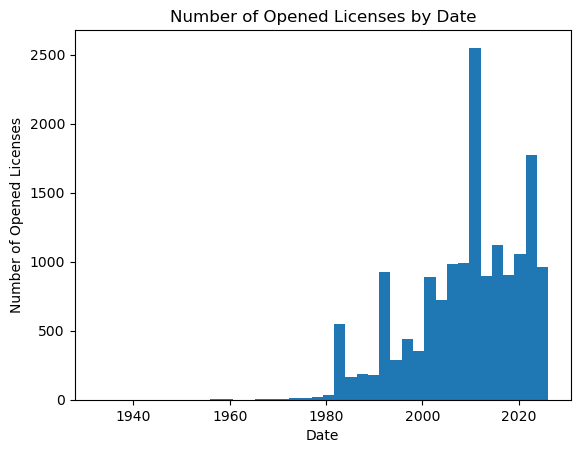

count                            16025
mean     2009-04-01 22:39:50.714508544
min                1932-07-01 00:00:00
25%                2002-06-07 00:00:00
50%                2010-09-15 00:00:00
75%                2018-07-30 00:00:00
max                2026-03-03 00:00:00
Name: Start date, dtype: object


In [3]:

license_data['Start date'].hist(
    bins=40,
)
plt.title("Number of Opened Licenses by Date")
plt.grid(False)
plt.xlabel("Date")
plt.ylabel("Number of Opened Licenses")
plt.show()
print(license_data['Start date'].describe())

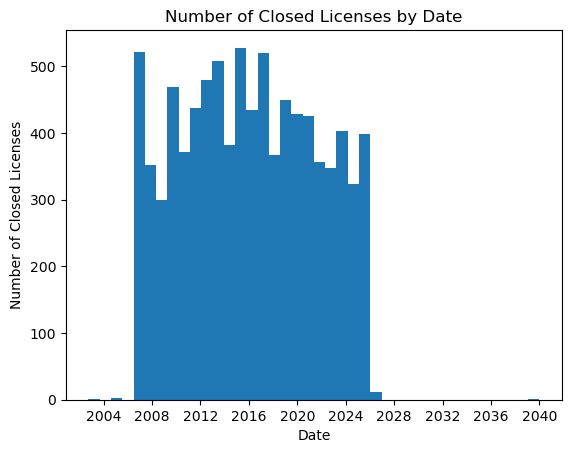

count                             8816
mean     2016-01-08 17:51:00.980036352
min                2002-09-30 00:00:00
25%                2011-06-30 00:00:00
50%                2015-12-02 12:00:00
75%                2020-06-30 00:00:00
max                2040-01-01 00:00:00
Name: Close date, dtype: object


In [4]:
license_data['Close date'].hist(
    bins=40,
)
plt.title("Number of Closed Licenses by Date")
plt.grid(False)
plt.xlabel("Date")
plt.ylabel("Number of Closed Licenses")
plt.show()
print(license_data['Close date'].describe())


In [5]:
close_times = pd.to_timedelta(pd.to_datetime(license_data['Close date'], format='%m/%d/%Y') - pd.to_datetime(license_data['Start date'], format='%m/%d/%Y'), unit='D').combine(pd.to_datetime(datetime.now()) -  pd.to_datetime(license_data['Start date']),
                  lambda d1,d2: d2 if d1 is None else d2).dt.days

close_times.name = 'closure_time'

censor = (~ license_data['Close date'].isna()).astype(int)

out_frame = close_times.to_frame()

out_frame['censor'] = censor

del close_times
del censor

out_frame

,closure_time,censor
0,7638,1
1,6114,1
2,5972,1
4,1795,0
5,6616,0
...,...,...
23759,1611,1
23760,11941,1
23761,5972,0
23763,9338,1


<Axes: title={'center': 'Number of Months until Business Closure'}, xlabel='Months', ylabel='Count'>

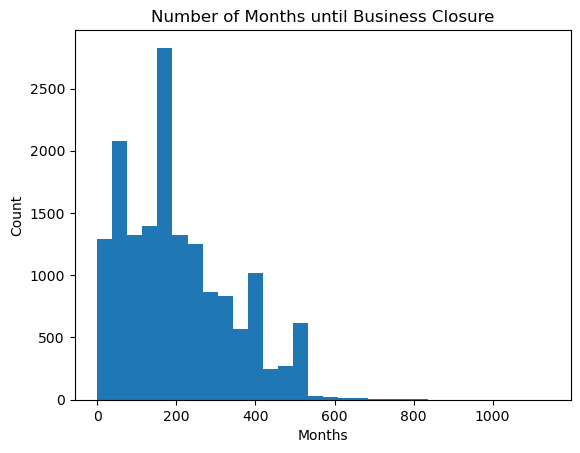

In [6]:
(out_frame['closure_time'] / 30).plot.hist(
    bins=30,
    xlabel='Months',
    ylabel='Count',
    title='Number of Months until Business Closure'
)

In [7]:
type_mappings = {
    "Downtown Association" : "Downtown Association",
    "Residential Rental" : "Rental",
    "Commercial Rental Property" : "Rental",
    "General Service" : "Service",
    "Professional Service" :"Service",
    "General Retailer" : "Retail",
    "Contractor" : "Service",
    "Message Therapist" : "Service",
    "General Manufacturer" : "Other",
    "General Wholesaler" : "Other",
    "Homestay Temporary TOT" : "Hotel",
    "Utilities/Transportation" : "Other",
    "Cannabis Permit Fee" : "Retail",
    "General Gun Dealer" : "Retail",
    "Cannabis Delivery Driver" : "Service"
}


out_frame['type'] = license_data['Rate type (STD)'].map(type_mappings)

del type_mappings
out_frame

,closure_time,censor,type
0,7638,1,Downtown Association
1,6114,1,Service
2,5972,1,Rental
4,1795,0,Retail
5,6616,0,Service
...,...,...,...
23759,1611,1,Service
23760,11941,1,Service
23761,5972,0,Retail
23763,9338,1,Other


# Adding Zoning Locations

In [8]:
zoning_map = get('https://mapsa.slocity.org/hosting/rest/services/sloGISlayers/gisLandManagementWM/MapServer/5/query?where=1%3D1&f=pjson').json()


zones = pd.json_normalize(zoning_map['features'])
zones = zones.explode(column='geometry.rings')


arcgis_to_lat_log = Transformer.from_crs("EPSG:3857", "EPSG:4326")

zones['polygon'] = zones['geometry.rings'].map(lambda x: [arcgis_to_lat_log.transform(point[0], point[1]) for point in x])

zones = gpd.GeoDataFrame(zones['attributes.generalZone'].rename('zone'), geometry=zones['polygon'].map(Polygon))

del arcgis_to_lat_log
del zoning_map
zones

,zone,geometry
0,R-1,"POLYGON ((35.266 -120.628, 35.265 -120.628, 35..."
1,C/OS,"POLYGON ((35.311 -120.694, 35.309 -120.694, 35..."
2,R-1,"POLYGON ((35.293 -120.649, 35.293 -120.649, 35..."
3,R-1,"POLYGON ((35.295 -120.647, 35.295 -120.647, 35..."
4,R-1,"POLYGON ((35.295 -120.648, 35.295 -120.648, 35..."
...,...,...
1320,R-1,"POLYGON ((35.251 -120.632, 35.251 -120.633, 35..."
1321,PF,"POLYGON ((35.252 -120.634, 35.252 -120.634, 35..."
1322,R-1,"POLYGON ((35.252 -120.633, 35.253 -120.633, 35..."
1323,PF,"POLYGON ((35.253 -120.634, 35.253 -120.634, 35..."


In [9]:
#Converted addresses to lat long with https://geocoding.geo.census.gov/geocoder/geographies/addressbatch

addr : pd.DataFrame = pd.concat([pd.read_csv('./addr1_p.csv',header=None),pd.read_csv('./addr2_p.csv',header=None)]).sort_values(by=0)


addr = pd.merge(out_frame.reset_index(),addr, left_on='index', right_on=0, how='left').drop(['index',0,6,7,8,9,10,11], axis=1)



out_frame['zone'] = addr[5].to_frame().map(lambda point: None if point is np.nan else zones['zone'][zones.distance(Point(point.split(",")[::-1])).idxmin()]) # Assign properties to the nearest zone.

In [11]:
out_frame.to_csv('BLSurvival.txt', index=False)